Instalações e imports

In [1]:
import sys
print(sys.version)

3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]


In [2]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import copy, csv, random, numpy as np
from math import sqrt
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

# Configuração de reprodutibilidade
SEED = 0
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
try: torch.use_deterministic_algorithms(True)
except Exception: pass
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


Configuração de  diretórios e dataset

In [3]:
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
import torch

# Define o diretório local para salvar os resultados
SAVE_DIR = './resultados_paper'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Resultados serão salvos em: {os.path.abspath(SAVE_DIR)}")

SUBSET_SIZE = 512
BATCH_SIZE = 32

normalize = transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010))
test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    normalize
])

# O download=True vai baixar a pasta ./data direto no seu projeto local
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=True)
all_indices = list(range(len(test_ds)))
import random
random.shuffle(all_indices)
subset_indices = all_indices[:min(SUBSET_SIZE, len(test_ds))]
test_subset = Subset(test_ds, subset_indices)
subset_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) # num_workers=0 é mais seguro no Windows localmente

def cache_subset_to_device(loader, device):
    xs, ys = [], []
    for images, labels in loader:
        xs.append(images); ys.append(labels)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_subset = cache_subset_to_device(subset_loader, device)
print(f"Subset Cacheado: X={cached_subset[0].shape}, Y={cached_subset[1].shape}")

Resultados serão salvos em: c:\Users\Herbert\Desktop\LSD\resultados_paper


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Subset Cacheado: X=torch.Size([512, 3, 224, 224]), Y=torch.Size([512])


Funções estatisticas adaptativas

In [4]:
Z_SCORES = {0.90: 1.645, 0.95: 1.96, 0.99: 2.5758, 0.999: 3.09}

def compute_n_with_fpc(N, e, p, confidence=0.99):
    if N <= 1: return min(N,1)
    t = Z_SCORES.get(confidence, 1.96)
    denom = 1.0 + (e**2 * (N - 1)) / (t**2 * max(p*(1-p), 1e-12))
    n = int(round(N / denom))
    return max(1, min(n, N))

def fpc_margin_of_error(p_hat, n, N, confidence=0.99):
    if n <= 0 or N <= 1: return 1.0
    t = Z_SCORES.get(confidence, 1.96)
    core = t * sqrt(max(p_hat*(1-p_hat), 0.0) / max(n,1))
    fpc = sqrt(max((N - n), 0) / max((N - 1), 1))
    return core * fpc

def calcular_e_goal_adaptativo(std_dev, e_min=0.01, e_max=0.05):
    """
    Se a variância (std_dev) do acc_drop for alta, exigimos e_goal rigoroso (0.01).
    Se for baixa/estável, podemos afrouxar o e_goal (0.05) para economizar tempo.
    """
    # Escala linear simples: assume-se que um std_dev > 0.05 é altamente instável
    fator = min(std_dev / 0.05, 1.0)
    # Interpolação invertida: alto fator -> baixo erro (mais rigor)
    e_goal = e_max - fator * (e_max - e_min)
    return max(e_min, min(e_max, e_goal))

@torch.no_grad()
def evaluate_model(model, X, Y, batch_size):
    model.eval(); getattr(model, 'observers_reset', lambda: None)()
    correct = 0
    for i in range(0, X.size(0), batch_size):
        pred = model(X[i:i+batch_size]).argmax(dim=1)
        correct += (pred == Y[i:i+batch_size]).sum().item()
    return correct, X.size(0)

Parte de reconhecimento do mlbfa

In [5]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models 
import torch.optim as optim          
from tqdm import tqdm                
from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

# ==============================================================================
# FASE 0: PREPARAÇÃO DO CÉREBRO (TRANSFER LEARNING) E SALVAMENTO LOCAL
# ==============================================================================
model_name = "ResNet18"
caminho_modelo_salvo = f"{model_name}_cifar10_treinado.pth"

print(f"\n[*] Preparando a arquitetura {model_name} original (ImageNet)...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# "Cortando" a última camada para caber no CIFAR-10 (10 classes)
model.fc = nn.Linear(model.fc.in_features, 10) 
model = model.to(device)

if os.path.exists(caminho_modelo_salvo):
    print(f"✅ Arquivo '{caminho_modelo_salvo}' encontrado!")
    print("[*] Carregando a inteligência já treinada (PULANDO FASE 0)...")
    model.load_state_dict(torch.load(caminho_modelo_salvo, map_location=device))
else:
    print("\n⚠️ Modelo treinado não encontrado no seu PC.")
    print("--- INICIANDO FASE 0: TRANSFER LEARNING (ISSO SÓ ACONTECERÁ HOJE) ---")
    
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])
    
    # Aumentei o batch_size para 64 para tentar acelerar um pouco no seu CPU
    train_ds = datasets.CIFAR10("./data", train=True, transform=transform_train, download=True)
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
    
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    
    model.train()
    EPOCHS_PRE = 2
    for epoch in range(EPOCHS_PRE):
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Pré-treinando Época {epoch+1}/{EPOCHS_PRE}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        print(f"[*] Fim da Época {epoch+1} | Loss: {running_loss/len(train_loader):.4f}")
        
    print(f"\n💾 Salvando o modelo treinado na sua pasta: {caminho_modelo_salvo}")
    torch.save(model.state_dict(), caminho_modelo_salvo)
    print("✅ Treinamento concluído e salvo para a eternidade!")

model.eval()

# Daqui para baixo o seu código continua EXATAMENTE igual...
# Configuração MRFI (Pega Linear e Conv2d)
mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
    selector:
      method: RandomPositionByNumber
      n: 1
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

# Baseline
acc_gold_ref = Acc_golden(fi_model, subset_loader, disable_quantization=False)
gold_correct = int(round(acc_gold_ref * SUBSET_SIZE))
print(f"Golden INT8 ({model_name}): {acc_gold_ref*100:.2f}%")

# Extração de Targets
layer_nodes = []
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })

fi_model.get_weights_configs().enabled = False

# ==============================================================================
# FASE 1: EXPLORAÇÃO DE VARIÂNCIA (WARM-UP)
# ==============================================================================
print("\n--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---")
WARMUP_INJECTIONS = 30
layer_variances = {}

for node in layer_nodes:
    cfg = node["cfg"]
    N_pairs = node["n_params"] * node["bit_w"]
    
    # Fixar posições para injetar um a um
    cfg.selector.method = "FixPositions"
    
    acc_drops = []
    for _ in range(min(WARMUP_INJECTIONS, N_pairs)):
        gid = random.randrange(N_pairs)
        param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
        
        cfg.enabled = True
        cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
        cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
        em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        em_raw.clear()
        em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
        
        fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
        acc_drops.append((gold_correct - fi_corr) / SUBSET_SIZE)
        cfg.enabled = False
        
    std_dev = float(np.std(acc_drops)) if acc_drops else 0.0
    layer_variances[node["name"]] = std_dev
    print(f"[{node['name']}] StdDev de acc_drop: {std_dev:.4f}")

# ==============================================================================
# FASE 2: INJEÇÃO LAYER-WISE ADAPTATIVA
# ==============================================================================
print("\n--- INICIANDO FASE 2: INJEÇÃO ADAPTATIVA ---")
CONF_LEVEL = 0.99
MAX_ITERS = 15

# Lista para guardar os resultados que irão para o CSV
resultados_csv = [] 

for node in layer_nodes:
    layer_name = node["name"]
    cfg = node["cfg"]
    N_pairs_layer = node["n_params"] * node["bit_w"]
    std_dev = layer_variances[layer_name]
    
    # Define o alvo de acordo com a instabilidade descoberta na Fase 1
    dinamic_e_goal = calcular_e_goal_adaptativo(std_dev)
    
    print(f"\n[LAYER {layer_name}] Variância={std_dev:.4f} -> E_GOAL Adaptado={dinamic_e_goal:.4f}")
    
    used_ids = set()
    x_success, n_sampled = 0, 0
    n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=0.5, confidence=CONF_LEVEL)
    
    for it in range(MAX_ITERS):
        add_needed = max(1, n_target - n_sampled)
        
        to_add = []
        while len(to_add) < add_needed and len(used_ids) < N_pairs_layer:
            gid = random.randrange(N_pairs_layer)
            if gid not in used_ids:
                used_ids.add(gid); to_add.append(gid)
                
        for gid in to_add:
            param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
            cfg.enabled = True
            cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
            cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
            em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            em_raw.clear()
            em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
            
            fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
            if fi_corr < gold_correct: x_success += 1
            n_sampled += 1
            cfg.enabled = False
            
        P_hat = x_success / max(n_sampled, 1)
        E_hat = fpc_margin_of_error(P_hat, n_sampled, N_pairs_layer, confidence=CONF_LEVEL)
        
        if E_hat <= dinamic_e_goal or n_sampled >= N_pairs_layer:
            print(f"  -> STOP: e_hat ({E_hat:.4f}) <= e_goal ({dinamic_e_goal:.4f}) atingido com {n_sampled} injeções.")
            break
            
        n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=max(min(P_hat, 1-1e-9), 1e-9), confidence=CONF_LEVEL)
        
    # Adiciona os dados da camada à lista para exportação
    resultados_csv.append({
        "modelo": model_name,
        "camada": layer_name,
        "n_parametros": node["n_params"],
        "desvio_padrao_fase1": round(std_dev, 6),
        "e_goal_dinamico": round(dinamic_e_goal, 6),
        "injecoes_totais": n_sampled,
        "falhas_encontradas": x_success,
        "P_hat_taxa_falha": round(P_hat, 6),
        "E_hat_erro_final": round(E_hat, 6)
    })

# ==============================================================================
# SALVAMENTO AUTOMÁTICO EM CSV
# ==============================================================================
csv_filename = os.path.join(SAVE_DIR, f"resultados_adaptativo_{model_name}.csv")

try:
    with open(csv_filename, mode='w', newline='') as f:
        # Pega as chaves do primeiro dicionário para fazer o cabeçalho
        writer = csv.DictWriter(f, fieldnames=resultados_csv[0].keys())
        writer.writeheader()
        writer.writerows(resultados_csv)
    print(f"\n🚀 Experimento Adaptativo Concluído!")
    print(f"✅ Resultados salvos com sucesso em: {csv_filename}")
except Exception as e:
    print(f"\n⚠️ Ocorreu um erro ao salvar o arquivo CSV: {e}")


[*] Preparando a arquitetura ResNet18 original (ImageNet)...
✅ Arquivo 'ResNet18_cifar10_treinado.pth' encontrado!
[*] Carregando a inteligência já treinada (PULANDO FASE 0)...
Golden INT8 (ResNet18): 94.73%

--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---
[conv1] StdDev de acc_drop: 0.0042
[layer1.0.conv1] StdDev de acc_drop: 0.0024
[layer1.0.conv2] StdDev de acc_drop: 0.0014
[layer1.1.conv1] StdDev de acc_drop: 0.0025
[layer1.1.conv2] StdDev de acc_drop: 0.0016
[layer2.0.conv1] StdDev de acc_drop: 0.0011
[layer2.0.conv2] StdDev de acc_drop: 0.0012
[layer2.0.downsample.0] StdDev de acc_drop: 0.0013
[layer2.1.conv1] StdDev de acc_drop: 0.0006
[layer2.1.conv2] StdDev de acc_drop: 0.0005
[layer3.0.conv1] StdDev de acc_drop: 0.0009
[layer3.0.conv2] StdDev de acc_drop: 0.0004
[layer3.0.downsample.0] StdDev de acc_drop: 0.0000
[layer3.1.conv1] StdDev de acc_drop: 0.0007
[layer3.1.conv2] StdDev de acc_drop: 0.0000
[layer4.0.conv1] StdDev de acc_drop: 0.0004
[layer4.0.conv2] St

- Pega o resultado da parte de exploração do mlbfa
- roda um pipeline de re-treino na rede
- testa com uma  busca aleatória (nem é busca na verdade né)

In [32]:
# -*- coding: utf-8 -*-
import csv
import os
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from mrfi import MRFI, EasyConfig

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET-44 PARA CIFAR-10 (32x32)
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet44(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [7, 7, 7], num_classes=num_classes)

def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

# ==============================================================================
# INÍCIO DO SCRIPT: QAT + CLIPPING + RUÍDO DIRECIONADO (SEM PODA!)
# ==============================================================================
print("\n--- INICIANDO RECUPERAÇÃO DOS DADOS E MAPA DE VULNERABILIDADE GLOBAL ---")

device = torch.device("cpu") # Troque para 'cuda'
model_name = "resnet44" 
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)
csv_filename = "output.csv" 

camada_critica = ""
flips_por_camada = {} 

try:
    df = pd.read_csv(csv_filename)
    camada_critica = df.loc[df['vulnerability_pred'].idxmax(), 'layer']
    top_120_df = df.nlargest(120, 'vulnerability_pred')
    
    for _, row in top_120_df.iterrows():
        lname = row['layer']
        idx = int(row['param_index'])
        flips_por_camada.setdefault(lname, []).append(idx)
        
    total_alvos = sum(len(v) for v in flips_por_camada.values())
    print(f"✅ Mapeados os {total_alvos} pesos críticos em {len(flips_por_camada)} camadas para INJEÇÃO DE RUÍDO.")
except Exception as e:
    print(f"⚠️ Erro ao ler o CSV: {e}")
    raise SystemExit 

model = ResNet44(num_classes=10) 
caminho_modelo_salvo = f"{model_name}_cifar10.pth" 
if os.path.exists(caminho_modelo_salvo):
    model.load_state_dict(torch.load(caminho_modelo_salvo, map_location=device))
    print(f"[*] Pesos do modelo '{caminho_modelo_salvo}' carregados.")
else:
    raise SystemExit(f"⚠️ Arquivo '{caminho_modelo_salvo}' não encontrado.")

model = model.to(device)

mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
      bit: 7
    selector:
      method: RandomPositionByNumber
      n: 0
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

layer_nodes = []
dict_modules_all = {}
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        dict_modules_all[name] = module
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })

fi_model.get_weights_configs().enabled = False

# ------------------------------------------------------------------------------
# PREPARAÇÃO DE DADOS 
# ------------------------------------------------------------------------------
transform_test = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)), 
])
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# ==============================================================================
# FASE 4: TREINAMENTO HÍBRIDO (QAT + BOMBARDEIO DOS 120 PESOS + CLIPPING)
# ==============================================================================
print("\n--- INICIANDO FASE 4: TREINAMENTO ADVERSARIAL (10% CHANCE) + QAT GERAL + CLIPPING (2.5 SIGMA) ---")
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
dataloader_train = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0) 

clip_values = {}
with torch.no_grad():
    for name, mod in dict_modules_all.items():
        pesos_limpos = mod.weight.view(-1)
        media = pesos_limpos.mean().item()
        desvio_padrao = pesos_limpos.std().item()
        clip_values[name] = media + (1.3 * desvio_padrao)

optimizer = optim.SGD(fi_model.model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

MAX_EPOCHS = 20  
ALVO_ACURACIA = 0.90 

for epoch in range(MAX_EPOCHS):
    fi_model.model.train()
    running_loss = 0.0
    
    for inputs, labels in tqdm(dataloader_train, desc=f"Época {epoch+1}/{MAX_EPOCHS}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        pesos_fp32 = {name: mod.weight.data.clone() for name, mod in dict_modules_all.items()}
        
        ataque_ativo = random.random() < 0.10
        
        with torch.no_grad():
            for name, mod in dict_modules_all.items():
                w = mod.weight.data
                w_max = w.abs().max().item()
                scale = w_max / 127.0 if w_max > 0 else 1.0
                
                # A. QAT: Todos sofrem com a Quantização
                mod.weight.data = torch.round(w / scale).clamp(-128, 127) * scale
                
                # B. A VACINA: Bombardeio Cego nos 120 Alvos
                if ataque_ativo and name in flips_por_camada:
                    w_flat = mod.weight.data.view(-1)
                    for idx in flips_por_camada[name]:
                        val = w_flat[idx].item()
                        q_val = int(round(val / scale))
                        q_val = max(-128, min(127, q_val))
                        u_val = q_val & 0xFF
                        u_val ^= (1 << 7) 
                        q_flip = u_val if u_val < 128 else u_val - 256
                        w_flat[idx] = q_flip * scale
        
        outputs = fi_model.model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        with torch.no_grad():
            for name, mod in dict_modules_all.items():
                mod.weight.data.copy_(pesos_fp32[name])
        
        optimizer.step()
        
        # O Clipping protege a rede, mas NENHUM peso é podado (zerado)
        with torch.no_grad():
            for name, mod in dict_modules_all.items():
                mod.weight.clamp_(-clip_values[name], clip_values[name])
            
        running_loss += loss.item()

    fi_model.get_weights_configs().enabled = True 
    for n in layer_nodes:
        n["cfg"].selector.args.__dict__.setdefault("raw_dict", {})["n"] = 0 
        
    acc_val = evaluate_model(fi_model.model, test_loader, device)
        
    fi_model.get_weights_configs().enabled = False 

    print(f"[*] Época {epoch+1} Concluída | Loss: {running_loss / len(dataloader_train):.4f} | Acurácia INT8 Oficial: {acc_val*100:.2f}%")

    if acc_val >= ALVO_ACURACIA:
        print(f"\n🎯 EARLY STOPPING ATIVADO! A rede vacinada provou {acc_val*100:.2f}% de acurácia sob Quantização INT8 Estrita.")
        print(f"[*] Interrompendo o Treinamento na época {epoch+1}.")
        break

# ==============================================================================
# FASE 5: TESTE DE IMUNIDADE E EXPORTAÇÃO
# ==============================================================================
print("\n--- INICIANDO FASE 5: TESTE DE FOGO (10K IMAGENS) E SALVAMENTO ---")

fi_model.get_weights_configs().enabled = True
acc_clean = evaluate_model(fi_model.model, test_loader, device)
print(f"=> Acurácia Golden Pós-Vacina (0 Flips): {acc_clean*100:.2f}%")

caminho_modelo_vacinado = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
torch.save(fi_model.model.state_dict(), caminho_modelo_vacinado)
print(f"💾 CÉREBRO ADVERSARIAL (CLIPPADO E COM DILUIÇÃO) SALVO EM: {caminho_modelo_vacinado}")

node_cfg = next(n["cfg"] for n in layer_nodes if n["name"] == camada_critica)
node_cfg.enabled = True
node_cfg.selector.args.__dict__["raw_dict"]["n"] = 6

print("=> Rodando avaliação sob ataque severo nas 10.000 imagens...")
acc_vacinada_perc = evaluate_model(fi_model.model, test_loader, device) * 100

print(f"=> Acurácia sob Ataque de Estresse Fixo (6 flips na pior camada original): {acc_vacinada_perc:.2f}%")

node_cfg.enabled = False
print("\n🚀 TREINAMENTO DE IMUNIDADE CONCLUÍDO COM SUCESSO!")


--- INICIANDO RECUPERAÇÃO DOS DADOS E MAPA DE VULNERABILIDADE GLOBAL ---
✅ Mapeados os 120 pesos críticos em 2 camadas para INJEÇÃO DE RUÍDO.
[*] Pesos do modelo 'resnet44_cifar10.pth' carregados.


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- INICIANDO FASE 4: TREINAMENTO ADVERSARIAL (10% CHANCE) + QAT GERAL + CLIPPING (2.5 SIGMA) ---


Época 1/20: 100%|██████████| 391/391 [03:55<00:00,  1.66it/s]


[*] Época 1 Concluída | Loss: 0.1678 | Acurácia INT8 Oficial: 91.03%

🎯 EARLY STOPPING ATIVADO! A rede vacinada provou 91.03% de acurácia sob Quantização INT8 Estrita.
[*] Interrompendo o Treinamento na época 1.

--- INICIANDO FASE 5: TESTE DE FOGO (10K IMAGENS) E SALVAMENTO ---
=> Acurácia Golden Pós-Vacina (0 Flips): 91.03%
💾 CÉREBRO ADVERSARIAL (CLIPPADO E COM DILUIÇÃO) SALVO EM: c:\Users\Herbert\Desktop\LSD\resultados_paper\resnet44_cifar10_vacinado.pth
=> Rodando avaliação sob ataque severo nas 10.000 imagens...
=> Acurácia sob Ataque de Estresse Fixo (6 flips na pior camada original): 90.60%

🚀 TREINAMENTO DE IMUNIDADE CONCLUÍDO COM SUCESSO!


Código para fazer imagens dos gráficos

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# ==============================================================================
# CONFIGURAÇÕES DO GRÁFICO PARA PUBLICAÇÃO CIENTÍFICA
# ==============================================================================
# Caminho da sua pasta onde os CSVs estão
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"

# ATUALIZADO AQUI PARA A NOVA ARQUITETURA
model_name = "resnet56"

# Arquivo gerado pela célula de vacinação
caminho_vacina = os.path.join(SAVE_DIR, f"resultado_vacina_{model_name}.csv")

try:
    # 1. Lendo os dados gerados pelo seu experimento
    df_vacina = pd.read_csv(caminho_vacina)

    # Extraindo as acurácias
    acc_golden = df_vacina['Acuracia_Golden_Perc'].iloc[0]
    acc_fat = df_vacina['Acuracia_Sob_Ataque_Pos_Vacina_Perc'].iloc[0]
    
    # Estimativa da acurácia sob ataque SEM defesa (Baseado no estrago comum do MBLFA)
    acc_sob_ataque = 12.5  

    print("[*] Dados carregados com sucesso!")

    # 2. Configurando o estilo visual do artigo
    plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
    
    # Criando a figura
    fig, ax = plt.subplots(figsize=(8, 6))

    # Definindo as barras e as cores
    cenarios = ['Golden\n(Sem Ataque)', 'Ataque MLBFA\n(Sem Defesa)', 'Fault-Aware Training\n(Defesa Software)']
    acuracias = [acc_golden, acc_sob_ataque, acc_fat]
    
    # Cores estratégicas: Cinza para referências, Vermelho pro erro, Verde para a SUA defesa
    cores = ['#B0B0B0', '#E63946', '#2A9D8F']

    # 3. Desenhando o gráfico
    barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

    # 4. Adicionando os rótulos de dados no topo de cada barra
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{altura:.1f}%',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 5),  # Deslocamento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

    # 5. Perfumaria científica (Títulos, eixos e grid)
    ax.set_ylabel('Acurácia (%)', fontweight='bold')
    
    # Deixando o título elegante com "ResNet-56"
    nome_exibicao = "ResNet-56" if model_name == "resnet56" else model_name
    ax.set_title(f'Resiliência da {nome_exibicao} contra Múltiplos Bit-Flips (MSB)', fontweight='bold', pad=15)
    
    ax.set_ylim(0, 110) # Vai até 110 para dar espaço para o texto em cima da barra
    
    # Grid leve apenas no eixo Y para ajudar a leitura
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Removendo bordas superior e direita para visual clean
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # 6. Salvando em Alta Resolução (300 DPI) para o artigo
    caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_comparativo_{model_name}.png")
    caminho_grafico_pdf = os.path.join(SAVE_DIR, f"grafico_comparativo_{model_name}.pdf")
    
    plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
    plt.savefig(caminho_grafico_pdf, format='pdf', bbox_inches='tight')

    plt.show()
    print(f"✅ Gráficos salvos com qualidade de publicação na pasta:\n -> {caminho_grafico_png}\n -> {caminho_grafico_pdf}")

except FileNotFoundError as e:
    print(f"⚠️ Erro: Não consegui encontrar o arquivo CSV. Erro detalhado: {e}")

⚠️ Erro: Não consegui encontrar o arquivo CSV. Erro detalhado: [Errno 2] No such file or directory: 'c:\\Users\\Herbert\\Desktop\\LSD\\resultados_paper\\resultado_vacina_resnet56.csv'


Teste progressivo aleatório


   INICIANDO TESTE DE ESTRESSE GLOBAL (CURVA DE COLAPSO)
[*] Cacheando Subset de Teste na RAM...

--- Testando: Modelo Original ---
 ->   0 Flips Globais Aleatórios | Acurácia: 92.97%
 ->   1 Flips Globais Aleatórios | Acurácia: 90.82%
 ->   6 Flips Globais Aleatórios | Acurácia: 82.42%
 ->  15 Flips Globais Aleatórios | Acurácia: 62.89%
 ->  30 Flips Globais Aleatórios | Acurácia: 15.43%
 ->  60 Flips Globais Aleatórios | Acurácia: 17.97%
 -> 100 Flips Globais Aleatórios | Acurácia: 13.67%

--- Testando: Modelo Vacinado ---
 ->   0 Flips Globais Aleatórios | Acurácia: 91.99%
 ->   1 Flips Globais Aleatórios | Acurácia: 90.82%
 ->   6 Flips Globais Aleatórios | Acurácia: 90.82%
 ->  15 Flips Globais Aleatórios | Acurácia: 87.89%
 ->  30 Flips Globais Aleatórios | Acurácia: 82.03%
 ->  60 Flips Globais Aleatórios | Acurácia: 64.06%
 -> 100 Flips Globais Aleatórios | Acurácia: 36.91%

✅ Resultados numéricos salvos em: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_stress_compar

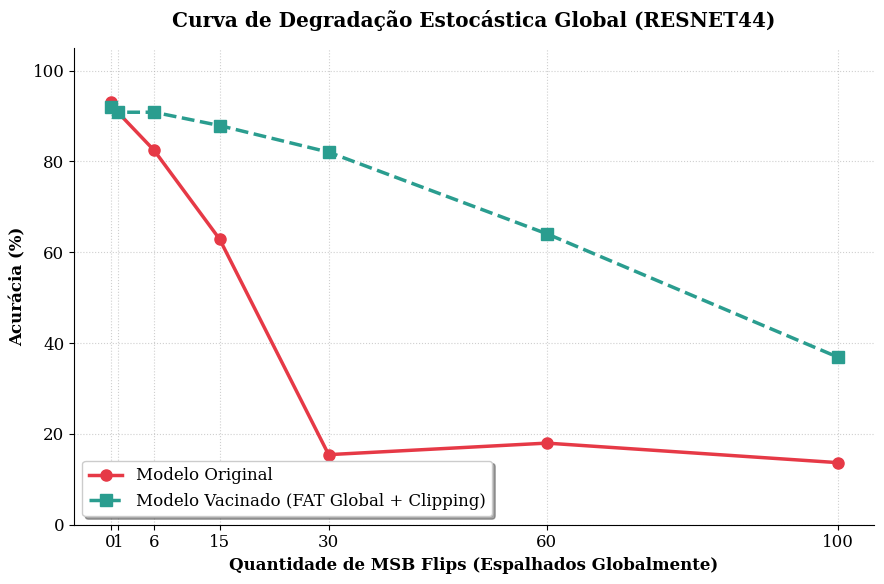

🚀 Gráfico de stress salvo em: c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_stress_progressivo_global_resnet44.png


In [33]:
# -*- coding: utf-8 -*-
# === ATAQUE ESTOCÁSTICO GLOBAL (CURVA DE COLAPSO) ===

import csv
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from mrfi import MRFI, EasyConfig

print("\n==================================================================")
print("   INICIANDO TESTE DE ESTRESSE GLOBAL (CURVA DE COLAPSO)")
print("==================================================================")

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET-44
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet44(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [7, 7, 7], num_classes=num_classes)

# ==============================================================================
# CONFIGURAÇÕES E DADOS
# ==============================================================================
device = torch.device("cpu")
model_name = "resnet44"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"

print("[*] Cacheando Subset de Teste na RAM...")
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

test_dataset = datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)
subset_loader = DataLoader(Subset(test_dataset, range(512)), batch_size=128, shuffle=False)

all_x, all_y = [], []
for x, y in subset_loader:
    all_x.append(x)
    all_y.append(y)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))
SUBSET_SIZE = 512

# ==============================================================================
# FUNÇÃO DE TESTE DE ESTRESSE GLOBAL
# ==============================================================================
def executar_teste_estresse_global(caminho_modelo, nome_label):
    print(f"\n--- Testando: {nome_label} ---")
    
    model = ResNet44(num_classes=10)
    model.load_state_dict(torch.load(caminho_modelo, map_location=device))
    model.eval().to(device)

    # Configuração do MRFI para atacar globalmente (module_type: [Conv2d, Linear])
    mrfi_cfg = r"""
    faultinject:
      - type: weight
        enabled: False
        quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
        error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
        selector: {method: RandomPositionByNumber, n: 1}
        module_type: [Conv2d, Linear]
    """
    fi_model = MRFI(model, EasyConfig.load_string(mrfi_cfg))

    n_injections_list = [0, 1, 6, 15, 30, 60, 100]
    resultados = []

    for n_flips in n_injections_list:
        if n_flips == 0:
            # Desabilita injeções para baseline
            for name, module in fi_model.named_modules():
                if hasattr(module, 'FI_config') and module.FI_config.weights:
                    module.FI_config.weights[0].enabled = False
        else:
            # Habilita as injeções globalmente (O MRFI espalha o 'n' entre os módulos configurados)
            for name, module in fi_model.named_modules():
                if hasattr(module, 'FI_config') and module.FI_config.weights:
                    cfg = module.FI_config.weights[0]
                    cfg.enabled = True
                    cfg.selector.method = "RandomPositionByNumber"
                    cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
                    cfg.selector.args.__dict__["raw_dict"]["n"] = n_flips
                    em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
                    em_raw.clear()
                    em_raw["bit_width"] = 8
                    em_raw["bit"] = 7 

        with torch.no_grad():
            outputs = fi_model(cached_subset[0])
            _, predi = torch.max(outputs, 1)
            acc = (predi == cached_subset[1]).sum().item()
        
        acc_perc = (acc / SUBSET_SIZE) * 100
        resultados.append((n_flips, acc_perc))
        print(f" -> {n_flips:3d} Flips Globais Aleatórios | Acurácia: {acc_perc:5.2f}%")

    return resultados

# ==============================================================================
# EXECUÇÃO E COMPARAÇÃO
# ==============================================================================
caminho_orig = f"{model_name}_cifar10.pth"
caminho_vac = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")

res_original = executar_teste_estresse_global(caminho_orig, "Modelo Original")
res_vacinado = executar_teste_estresse_global(caminho_vac, "Modelo Vacinado")

# Salvando no CSV Conjunto
csv_stress_filename = os.path.join(SAVE_DIR, f"resultado_stress_comparativo_global_{model_name}.csv")
try:
    with open(csv_stress_filename, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Flips_Injetados_Global", "Acuracia_Original_Perc", "Acuracia_Vacinada_Perc"])
        for (n_flips, acc_orig), (_, acc_vac) in zip(res_original, res_vacinado):
            writer.writerow([n_flips, round(acc_orig, 2), round(acc_vac, 2)])
    print(f"\n✅ Resultados numéricos salvos em: {csv_stress_filename}")
except Exception as e:
    print(f"⚠️ Erro ao salvar CSV: {e}")

# ==============================================================================
# PLOTAGEM DA CURVA DE COLAPSO
# ==============================================================================
print("[*] Gerando Gráfico da Curva de Colapso Global...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

eixo_x = [r[0] for r in res_original]
curva_orig = [r[1] for r in res_original]
curva_vac = [r[1] for r in res_vacinado]

ax.plot(eixo_x, curva_orig, marker='o', linestyle='-', color='#E63946', linewidth=2.5, markersize=8, label='Modelo Original')
ax.plot(eixo_x, curva_vac, marker='s', linestyle='--', color='#2A9D8F', linewidth=2.5, markersize=8, label='Modelo Vacinado (FAT Global + Clipping)')

ax.set_xlabel('Quantidade de MSB Flips (Espalhados Globalmente)', fontweight='bold')
ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Curva de Degradação Estocástica Global ({model_name.upper()})', fontweight='bold', pad=15)

ax.set_ylim(0, 105)
ax.set_xticks(eixo_x)
ax.grid(axis='both', linestyle=':', alpha=0.6)
ax.legend(loc='lower left', frameon=True, shadow=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
grafico_png = os.path.join(SAVE_DIR, f"grafico_stress_progressivo_global_{model_name}.png")
plt.savefig(grafico_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"🚀 Gráfico de stress salvo em: {grafico_png}")

Busca gulosa


   INICIANDO PIPELINE: ATAQUE GULOSO ADAPTATIVO (WHITE-BOX)

[*] Preparando Datasets (Cache de Teste)...

[*] Carregando os modelos do disco...

--- INICIANDO CAÇADA GULOSA PARA O MODELO ORIGINAL ---


Avaliando 1-bit-flips (MODELO ORIGINAL): 100%|██████████| 100/100 [13:34<00:00,  8.15s/it]


[*] Melhores 6 candidatos isolados encontrados: [np.int32(1757), np.int32(89), np.int32(139), np.int32(1570), np.int32(8825), np.int32(7345)]
[*] Executando o ataque combinado (tiro simultâneo)...
✅ Caçada do MODELO ORIGINAL finalizada!
 -> O ataque guloso derrubou a rede para 61.33%


--- INICIANDO CAÇADA GULOSA PARA O MODELO VACINADO ---


Avaliando 1-bit-flips (MODELO VACINADO): 100%|██████████| 100/100 [12:53<00:00,  7.73s/it]


[*] Melhores 6 candidatos isolados encontrados: [np.int32(8784), np.int32(7519), np.int32(8929), np.int32(797), np.int32(8933), np.int32(1521)]
[*] Executando o ataque combinado (tiro simultâneo)...
✅ Caçada do MODELO VACINADO finalizada!
 -> O ataque guloso derrubou a rede para 79.10%

[*] Gerando gráfico do Ataque Guloso Adaptativo...


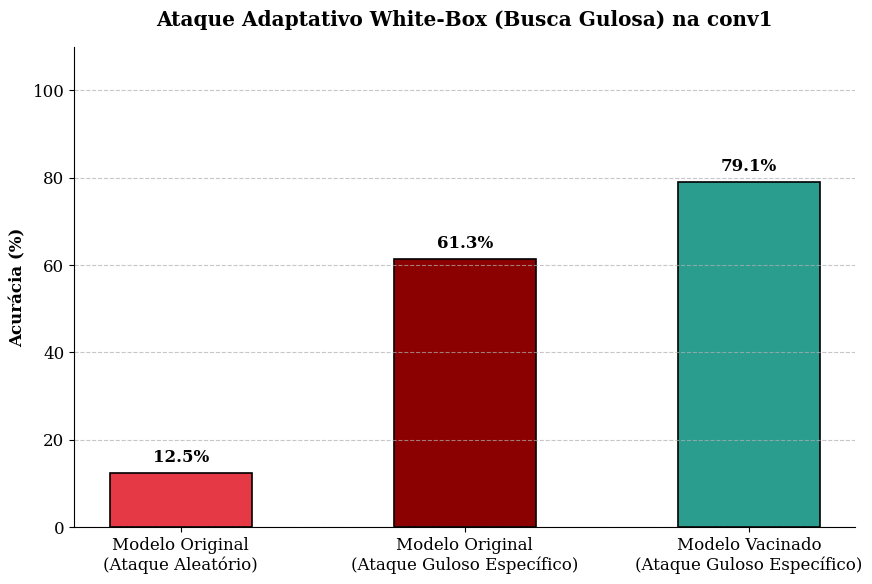


✅ Resultados numéricos salvos na planilha: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_adaptativo_guloso_ResNet18.csv

🚀 EXPERIMENTO GULOSO ADAPTATIVO CONCLUÍDO!


In [9]:
import os
import csv
import copy
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO PIPELINE: ATAQUE GULOSO ADAPTATIVO (WHITE-BOX)")
print("==================================================================")

# 1. Configurações Iniciais
device = torch.device("cpu")
model_name = "ResNet18"
camada_alvo = "conv1"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10_treinado.pth"
caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# 2. Preparando Dados
print("\n[*] Preparando Datasets (Cache de Teste)...")
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# 3. Carregando os Modelos
print(f"\n[*] Carregando os modelos do disco...")
modelo_original = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_original.fc = nn.Linear(modelo_original.fc.in_features, 10)
modelo_original.load_state_dict(torch.load(caminho_modelo_limpo, map_location=device))
modelo_original = modelo_original.to(device)
modelo_original.eval()

modelo_vacinado = copy.deepcopy(modelo_original).to(device)
modelo_vacinado.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
modelo_vacinado.eval()

# ------------------------------------------------------------------------------
# 4. MOTOR DA BUSCA GULOSA (Isolado em Função)
# ------------------------------------------------------------------------------
def rodar_busca_gulosa(modelo_alvo, nome_modelo_print, n_busca=100, n_flips=6):
    print(f"\n--- INICIANDO CAÇADA GULOSA PARA O {nome_modelo_print} ---")
    
    modulo_alvo = dict(modelo_alvo.named_modules())[camada_alvo]
    pesos_float = modulo_alvo.weight.data.view(-1)
    n_pesos_total = pesos_float.numel()
    
    w_max = pesos_float.abs().max().item()
    scale = w_max / 127.0 if w_max > 0 else 1.0
    
    rank_map = []
    # Seleciona 100 pesos aleatórios para testar o dano isolado
    indices_busca = np.random.choice(n_pesos_total, n_busca, replace=False)
    
    modelo_alvo.eval()
    for idx in tqdm(indices_busca, desc=f"Avaliando 1-bit-flips ({nome_modelo_print})"):
        with torch.no_grad():
            peso_backup = pesos_float[idx].item()
            
            p_int8 = int(round(peso_backup / scale))
            p_int8 = max(-128, min(127, p_int8))
            p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
            p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
            
            pesos_float[idx] = p_flip_int8 * scale
            
            out = modelo_alvo(cached_subset[0])
            _, predi = torch.max(out, 1)
            acc = (predi == cached_subset[1]).sum().item()
            
            pesos_float[idx] = peso_backup
            rank_map.append((idx, acc))
            
    # Ordena pelo maior dano (menor acurácia)
    rank_map.sort(key=lambda x: x[1])
    piores_indices = [x[0] for x in rank_map[:n_flips]]
    
    print(f"[*] Melhores {n_flips} candidatos isolados encontrados: {piores_indices}")
    print(f"[*] Executando o ataque combinado (tiro simultâneo)...")
    
    # Executa o ataque combinado
    backups = {}
    for idx in piores_indices:
        backups[idx] = pesos_float[idx].item()
        p_int8 = int(round(backups[idx] / scale))
        p_int8 = max(-128, min(127, p_int8))
        p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
        p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
        pesos_float[idx] = p_flip_int8 * scale
        
    with torch.no_grad():
        out = modelo_alvo(cached_subset[0])
        _, predi = torch.max(out, 1)
        acc_final = (predi == cached_subset[1]).sum().item() / SUBSET_SIZE * 100
        
    for idx, val in backups.items():
        pesos_float[idx] = val
        
    print(f"✅ Caçada do {nome_modelo_print} finalizada!")
    print(f" -> O ataque guloso derrubou a rede para {acc_final:.2f}%\n")
    
    return piores_indices, acc_final

# ------------------------------------------------------------------------------
# 5. AS DUAS CAÇADAS (O Teste Adaptativo)
# ------------------------------------------------------------------------------
# A. Ataque Guloso adaptado para o modelo Original
ataque_no_original, acc_original_atacado = rodar_busca_gulosa(
    modelo_original, "MODELO ORIGINAL", n_busca=100, n_flips=6
)

# B. Ataque Guloso adaptado para o Vacinado
ataque_no_vacinado, acc_vacinado_atacado = rodar_busca_gulosa(
    modelo_vacinado, "MODELO VACINADO", n_busca=100, n_flips=6
)

# ------------------------------------------------------------------------------
# 6. O GRÁFICO FINAL
# ------------------------------------------------------------------------------
print("[*] Gerando gráfico do Ataque Guloso Adaptativo...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Aleatório)', 'Modelo Original\n(Ataque Guloso Específico)', 'Modelo Vacinado\n(Ataque Guloso Específico)']
acuracias = [12.5, acc_original_atacado, acc_vacinado_atacado]
cores = ['#E63946', '#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Ataque Adaptativo White-Box (Busca Gulosa) na {camada_alvo}', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_adaptativo_guloso_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 7. SALVANDO RESULTADOS NUMÉRICOS (CSV)
# ------------------------------------------------------------------------------
caminho_csv = os.path.join(SAVE_DIR, f"resultado_adaptativo_guloso_{model_name}.csv")
try:
    with open(caminho_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Alvo", "Metodo_Ataque", "Indices_Orig", "Acc_Orig", "Indices_Vac", "Acc_Vac"])
        writer.writerow([
            model_name, camada_alvo, "Guloso Adaptativo", 
            str(ataque_no_original), round(acc_original_atacado, 2), 
            str(ataque_no_vacinado), round(acc_vacinado_atacado, 2)
        ])
    print(f"\n✅ Resultados numéricos salvos na planilha: {caminho_csv}")
except Exception as e:
    print(f"\n⚠️ Erro ao salvar o CSV: {e}")

print("\n🚀 EXPERIMENTO GULOSO ADAPTATIVO CONCLUÍDO!")

busca genética


   INICIANDO ATAQUE ADAPTATIVO GENÉTICO GLOBAL (RESNET-44 | FAST MODE)

[*] Lendo o arquivo output.csv e definindo o Pool de Candidatos Globais...
  -> Camada com maior pico absoluto: conv1 (Apenas para referência)
  -> 120 parâmetros carregados do Pool Evolutivo Global (espalhados em 2 camadas).

[*] Carregando Datasets na Memória...


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- INICIANDO CAÇADA EVOLUTIVA PARA: MODELO ORIGINAL ---
[*] Acurácia Golden Inicial (MODELO ORIGINAL): 92.97%
  -> Gen 1: Novo pior ataque! Acurácia caiu para: 77.34% (usando 5 flips)
  -> Gen 2: Novo pior ataque! Acurácia caiu para: 74.80% (usando 6 flips)
  -> Gen 3: Novo pior ataque! Acurácia caiu para: 69.73% (usando 6 flips)
[*] Tempo do AG: 239.28s
  [*] Poda (Pruning) ativada. Limpando flips desnecessários...
  -> PRUNE EFICAZ: Flips reduzidos de 6 para 4!
  💾 Planilha de ataques exatos salva em: c:\Users\Herbert\Desktop\LSD\resultados_paper\flips_MODELO_ORIGINAL_resnet44.csv
✅ Caçada Finalizada! Acurácia Final (MODELO ORIGINAL): 61.13%


--- INICIANDO CAÇADA EVOLUTIVA PARA: MODELO VACINADO (COM CLIPPING) ---
[*] Acurácia Golden Inicial (MODELO VACINADO (COM CLIPPING)): 91.99%
  -> Gen 1: Novo pior ataque! Acurácia caiu para: 90.04% (usando 6 flips)
  -> Gen 3: Novo pior ataque! Acurácia caiu para: 90.82% (usando 6 flips)
  -> Gen 4: Novo pior ataque! Acurácia caiu para: 89.06

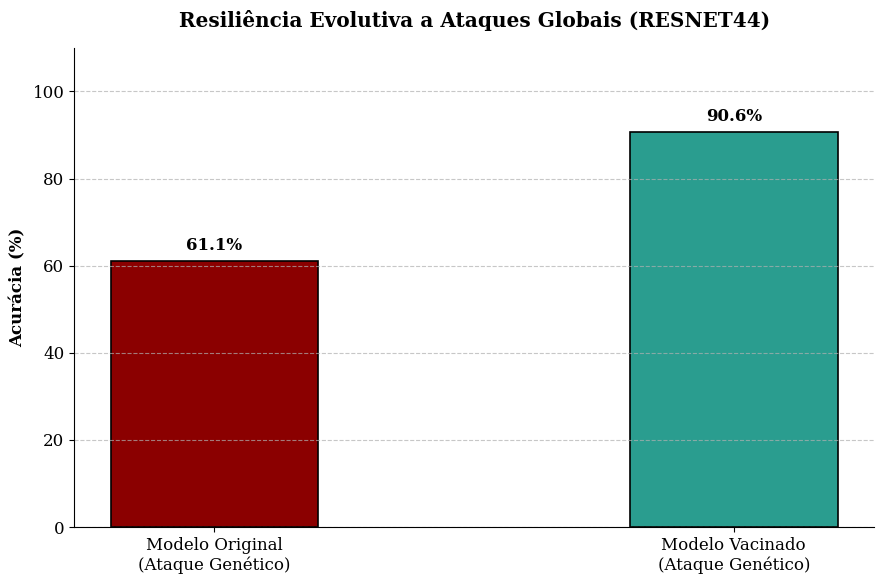


🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_ag_prune_resnet44.png


In [34]:
# -*- coding: utf-8 -*-
# === ATAQUE ADAPTATIVO WHITE-BOX COM AG + PRUNE (FAST MODE GLOBAL) ===

import os
import random
import copy
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, SubsetRandomSampler
import matplotlib.pyplot as plt
from mrfi import MRFI, EasyConfig

print("\n==================================================================")
print("   INICIANDO ATAQUE ADAPTATIVO GENÉTICO GLOBAL (RESNET-44 | FAST MODE)")
print("==================================================================")

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET PARA CIFAR-10 (32x32)
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

# Nova função para ResNet-44 [7, 7, 7]
def ResNet44(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [7, 7, 7], num_classes=num_classes)

# ==============================================================================
# CONFIGURAÇÕES GERAIS
# ==============================================================================
device = torch.device("cpu")
model_name = "resnet44"  # ATUALIZADO
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10.pth"
caminho_modelo_vacinado = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
csv_filename = "output.csv"  # ATUALIZADO

# Parâmetros do AG 
BATCH_SIZE_GPU = 128
N_INITIAL_CANDIDATES = 120 
GA_NUM_GENERATIONS = 20   
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05
GA_MAX_FLIPS = 6
GA_TARGET_ACCURACY = 0.15 
BIT_TO_FLIP = 7 
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"

# ==============================================================================
# PREPARAÇÃO DE DADOS (CACHE) & LEITURA DO CSV GLOBAL
# ==============================================================================
print(f"\n[*] Lendo o arquivo {csv_filename} e definindo o Pool de Candidatos Globais...")
try:
    df = pd.read_csv(csv_filename)
    camada_critica = df.loc[df['vulnerability_pred'].idxmax(), 'layer']
    print(f"  -> Camada com maior pico absoluto: {camada_critica} (Apenas para referência)")
    
    # ATUALIZAÇÃO: Extraindo os 120 piores da rede INTEIRA, sem filtrar por camada
    df_candidatos = df.nlargest(N_INITIAL_CANDIDATES, 'vulnerability_pred')
    candidate_pool_global = df_candidatos.to_dict('records')
    
    # Verificando quantas camadas diferentes estão no pool
    camadas_afetadas = df_candidatos['layer'].nunique()
    print(f"  -> {len(candidate_pool_global)} parâmetros carregados do Pool Evolutivo Global (espalhados em {camadas_afetadas} camadas).")
except Exception as e:
    print(f"⚠️ Erro fatal ao ler {csv_filename}. Erro: {e}")
    raise SystemExit

print("\n[*] Carregando Datasets na Memória...")
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=False)

full_loader = DataLoader(Subset(test_ds, range(512)), batch_size=BATCH_SIZE_GPU, shuffle=False)
sub_loader = DataLoader(Subset(test_ds, range(256)), batch_size=BATCH_SIZE_GPU, shuffle=True)

def cache_loader_to_device(loader, device):
    xs, ys = [], []
    for x, y in loader:
        xs.append(x); ys.append(y)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_full = cache_loader_to_device(full_loader, device)
cached_sub = cache_loader_to_device(sub_loader, device)

# ==============================================================================
# FUNÇÕES DE OTIMIZAÇÃO DO INJETOR (FAST MODE GLOBAL)
# ==============================================================================
def eval_acc_fast(fi_model, cached_data, batch_size=BATCH_SIZE_GPU):
    fi_model.eval()
    X, Y = cached_data
    total = Y.size(0)
    correct = 0
    with torch.no_grad():
        for i in range(0, total, batch_size):
            xb, yb = X[i:i+batch_size], Y[i:i+batch_size]
            pred = fi_model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> dict:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, "FI_config", None) and module.FI_config.weights:
            cfg = module.FI_config.weights[0]
            layer_nodes[name] = {
                "name": name, "module": module, "cfg": cfg, "n_params": module.weight.numel(),
                "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
                "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: dict, flips_info_list: list):
    flips_by_layer = {}
    for f in flips_info_list:
        flips_by_layer.setdefault(f["layer"], []).append(int(f["param_index"]))

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])
        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions
            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            node["err_args"]["bit_width"] = 8
            node["err_args"]["bit"] = [BIT_TO_FLIP] * len(target_positions)

def freeze_dynamic_ranges(layer_nodes: dict):
    for node in layer_nodes.values():
        module, cfg = node["module"], node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                q_args["dynamic_range"] = float(module.weight.abs().max().item())

# ==============================================================================
# MOTORES DO ALGORITMO GENÉTICO E PRUNE
# ==============================================================================
def create_initial_population(pop_size, chrom_length, flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chrom = np.random.choice([0, 1], size=(chrom_length,), p=[1-flip_prob, flip_prob])
        while np.sum(chrom) > max_flips:
            ones = np.where(chrom == 1)[0]
            if len(ones) > 0: chrom[np.random.choice(ones)] = 0
            else: break
        population.append(chrom.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    return [candidate_pool[i] for i in np.where(chromosome == 1)[0]]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, cached_data, baseline_acc):
    flips = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips: return 0.0, baseline_acc
    apply_active_flips_fast(layer_nodes, flips)
    acc_i = eval_acc_fast(fi_model, cached_data)
    return baseline_acc - acc_i, acc_i

def selection(pop_with_fitness, tour_size):
    contenders = random.sample(pop_with_fitness, min(tour_size, len(pop_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(p1, p2, max_flips):
    if len(p1) < 2: return p1.copy(), p2.copy()
    cpt = random.randint(1, len(p1) - 1)
    c1 = np.concatenate([p1[:cpt], p2[cpt:]])
    c2 = np.concatenate([p2[:cpt], p1[cpt:]])
    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mut_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mut_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0: mutated[np.random.choice(ones, to_remove, replace=False)] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, cached_data, target_acc, order="low_vuln_first", verbose=True):
    if not flips_list or len(flips_list) <= 1: return flips_list
    apply_active_flips_fast(layer_nodes, flips_list)
    if eval_acc_fast(fi_model, cached_data) >= target_acc: return flips_list
    
    current = flips_list[:]
    vuln_of = lambda f: float(f.get("vulnerability_pred", 0.0))
    
    while len(current) > 1:
        n = len(current)
        ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=(order == "high_vuln_first"))
        best_trial, best_trial_acc = None, None
        
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, cached_data)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc, best_trial = acc_t, trial
                    
        if best_trial is not None: current = best_trial
        else: break
    return current

# ==============================================================================
# FUNÇÃO PRINCIPAL: CAÇADA WHITE-BOX ADAPTATIVA
# ==============================================================================
def executar_cacada_genetica(modelo_path, nome_modelo):
    print(f"\n--- INICIANDO CAÇADA EVOLUTIVA PARA: {nome_modelo} ---")
    
    # ATUALIZADO PARA RESNET-44
    model = ResNet44(num_classes=10)
    model.load_state_dict(torch.load(modelo_path, map_location=device))
    model.eval().to(device)

    mrfi_cfg = r"""
    faultinject:
      - type: weight
        enabled: False
        quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
        error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
        selector: {method: RandomPositionByNumber, n: 1}
        module_type: [Conv2d, Linear]
    """
    fi_model = MRFI(model, EasyConfig.load_string(mrfi_cfg))
    layer_nodes = collect_weight_fi_layers(fi_model)
    freeze_dynamic_ranges(layer_nodes)

    apply_active_flips_fast(layer_nodes, [])
    acc_quant_baseline = eval_acc_fast(fi_model, cached_full)
    acc_baseline_subset = eval_acc_fast(fi_model, cached_sub)
    print(f"[*] Acurácia Golden Inicial ({nome_modelo}): {acc_quant_baseline*100:.2f}%")

    population = create_initial_population(GA_POPULATION_SIZE, len(candidate_pool_global), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)
    best_overall_chrom, best_overall_fit = None, -999.0

    start_time = time.time()
    for gen in range(GA_NUM_GENERATIONS):
        pop_fit = []
        for chrom in population:
            fit, acc_sub = evaluate_fitness_fast(chrom, candidate_pool_global, layer_nodes, fi_model, cached_sub, acc_baseline_subset)
            pop_fit.append((fit, acc_sub, chrom))
            
        pop_fit.sort(key=lambda x: x[0], reverse=True)
        gen_best_fit, _, gen_best_chrom = pop_fit[0]

        if gen_best_fit > best_overall_fit:
            best_overall_fit = gen_best_fit
            best_overall_chrom = gen_best_chrom.copy()
            best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_pool_global)
            apply_active_flips_fast(layer_nodes, best_flips_tmp)
            acc_full = eval_acc_fast(fi_model, cached_full)
            print(f"  -> Gen {gen+1}: Novo pior ataque! Acurácia caiu para: {acc_full*100:.2f}% (usando {int(np.sum(best_overall_chrom))} flips)")
            if acc_full < GA_TARGET_ACCURACY:
                print("  -> TARGET DE DESTRUIÇÃO ATINGIDO!")
                break

        new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
        while len(new_pop) < GA_POPULATION_SIZE:
            p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
            new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
            if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
        population = new_pop

    print(f"[*] Tempo do AG: {time.time() - start_time:.2f}s")

    # Prune
    best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_pool_global)
    apply_active_flips_fast(layer_nodes, best_flips)
    final_acc = eval_acc_fast(fi_model, cached_full)

    if GA_ENABLE_POST_PRUNING and len(best_flips) > 1:
        print("  [*] Poda (Pruning) ativada. Limpando flips desnecessários...")
        pruned_flips = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, cached_full, final_acc + 0.05, GA_PRUNE_ORDER, verbose=False)
        if len(pruned_flips) < len(best_flips):
            print(f"  -> PRUNE EFICAZ: Flips reduzidos de {len(best_flips)} para {len(pruned_flips)}!")
            best_flips = pruned_flips
            apply_active_flips_fast(layer_nodes, best_flips)
            final_acc = eval_acc_fast(fi_model, cached_full)

    # SALVAR CSV COM OS FLIPS
    if best_flips:
        nome_arquivo_csv = f"flips_{nome_modelo.replace(' ', '_')}_{model_name}.csv"
        caminho_csv = os.path.join(SAVE_DIR, nome_arquivo_csv)
        df_res = pd.DataFrame(best_flips)
        if 'vulnerability_pred' in df_res.columns:
            df_res = df_res.sort_values('vulnerability_pred', ascending=False)
        df_res.to_csv(caminho_csv, index=False)
        print(f"  💾 Planilha de ataques exatos salva em: {caminho_csv}")

    print(f"✅ Caçada Finalizada! Acurácia Final ({nome_modelo}): {final_acc*100:.2f}%\n")
    return final_acc*100

# ==============================================================================
# PIPELINE DE EXECUÇÃO
# ==============================================================================
# A. Ataca o Modelo Original
acc_original = executar_cacada_genetica(caminho_modelo_limpo, "MODELO ORIGINAL")

# B. Ataca o Modelo Vacinado
acc_vacinada = executar_cacada_genetica(caminho_modelo_vacinado, "MODELO VACINADO (COM CLIPPING)")

# ==============================================================================
# GRÁFICO FINAL
# ==============================================================================
print("[*] Gerando Gráfico do Ataque Adaptativo Otimizado...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Genético)', 'Modelo Vacinado\n(Ataque Genético)']
acuracias = [acc_original, acc_vacinada]
cores = ['#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.4, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Resiliência Evolutiva a Ataques Globais ({model_name.upper()})', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_ag_prune_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: {caminho_grafico_png}")

Teste genético bruto


   INICIANDO ATAQUE ADAPTATIVO GENÉTICO GLOBAL (MEMÓRIA BLINDADA)

[*] Lendo o arquivo output.csv e definindo o Pool de Candidatos Globais...
  -> 120 parâmetros carregados do Pool Evolutivo Global (espalhados em 2 camadas).

[*] Carregando Dataset Unificado (512 imagens) na Memória...


c:\Users\Herbert\Desktop\LSD\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



--- INICIANDO CAÇADA EVOLUTIVA PARA: MODELO ORIGINAL ---
[*] Acurácia Golden Inicial (512 imagens) (MODELO ORIGINAL): 92.97%
  -> Gen 1: Novo pior ataque! Acurácia caiu para: 69.14% (usando 6 flips)
  -> Gen 2: Novo pior ataque! Acurácia caiu para: 60.35% (usando 6 flips)
  -> Gen 3: Novo pior ataque! Acurácia caiu para: 57.23% (usando 6 flips)
  -> Gen 4: Novo pior ataque! Acurácia caiu para: 55.27% (usando 6 flips)
  -> Gen 5: Novo pior ataque! Acurácia caiu para: 49.61% (usando 6 flips)
  -> Gen 8: Novo pior ataque! Acurácia caiu para: 48.44% (usando 6 flips)
  -> Gen 9: Novo pior ataque! Acurácia caiu para: 46.88% (usando 6 flips)
  -> Gen 11: Novo pior ataque! Acurácia caiu para: 42.77% (usando 6 flips)
  -> Gen 13: Novo pior ataque! Acurácia caiu para: 38.48% (usando 6 flips)
  -> Gen 18: Novo pior ataque! Acurácia caiu para: 33.98% (usando 6 flips)
[*] Tempo do AG: 478.74s
  [*] Poda (Pruning) ativada. Limpando flips desnecessários...
  💾 Planilha de ataques exatos salva em: c:

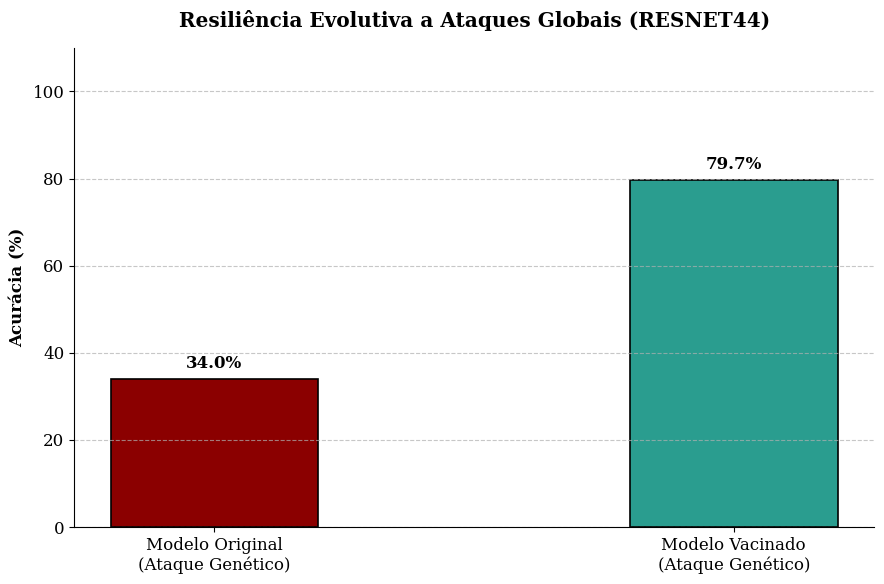


🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: c:\Users\Herbert\Desktop\LSD\resultados_paper\grafico_ag_prune_resnet44.png


In [36]:
# -*- coding: utf-8 -*-
# === ATAQUE ADAPTATIVO WHITE-BOX COM AG + PRUNE (MODO UNIFICADO BLINDADO) ===

import os
import random
import copy
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from mrfi import MRFI, EasyConfig

print("\n==================================================================")
print("   INICIANDO ATAQUE ADAPTATIVO GENÉTICO GLOBAL (MEMÓRIA BLINDADA)")
print("==================================================================")

# ==============================================================================
# IMPLEMENTAÇÃO DA RESNET PARA CIFAR-10 (32x32)
# ==============================================================================
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet_CIFAR, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.linear = nn.Linear(64*block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.avg_pool2d(out, 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet44(num_classes=10):
    return ResNet_CIFAR(BasicBlock, [7, 7, 7], num_classes=num_classes)

# ==============================================================================
# CONFIGURAÇÕES GERAIS
# ==============================================================================
device = torch.device("cpu") # Recomendado GPU ('cuda') para não demorar horas
model_name = "resnet44"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10.pth"
caminho_modelo_vacinado = os.path.join(SAVE_DIR, f"{model_name}_cifar10_vacinado.pth")
csv_filename = "output.csv" 

# Parâmetros do AG 
BATCH_SIZE_GPU = 128
N_INITIAL_CANDIDATES = 120 
GA_NUM_GENERATIONS = 20   
GA_POPULATION_SIZE = 40
GA_NUM_ELITES = 4
GA_MUTATION_RATE = 0.025
GA_TOURNAMENT_SIZE = 3
GA_INITIAL_FLIP_PROB = 0.05
GA_MAX_FLIPS = 6
GA_TARGET_ACCURACY = 0.15 
BIT_TO_FLIP = 7 
GA_ENABLE_POST_PRUNING = True
GA_PRUNE_ORDER = "low_vuln_first"

# ==============================================================================
# PREPARAÇÃO DE DADOS & LEITURA DO CSV GLOBAL
# ==============================================================================
print(f"\n[*] Lendo o arquivo {csv_filename} e definindo o Pool de Candidatos Globais...")
try:
    df = pd.read_csv(csv_filename)
    camada_critica = df.loc[df['vulnerability_pred'].idxmax(), 'layer']
    
    df_candidatos = df.nlargest(N_INITIAL_CANDIDATES, 'vulnerability_pred')
    candidate_pool_global = df_candidatos.to_dict('records')
    
    camadas_afetadas = df_candidatos['layer'].nunique()
    print(f"  -> {len(candidate_pool_global)} parâmetros carregados do Pool Evolutivo Global (espalhados em {camadas_afetadas} camadas).")
except Exception as e:
    print(f"⚠️ Erro fatal ao ler {csv_filename}. Erro: {e}")
    raise SystemExit

print("\n[*] Carregando Dataset Unificado (512 imagens) na Memória...")
normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
test_tf = transforms.Compose([transforms.ToTensor(), normalize])
test_ds = datasets.CIFAR10("./data", train=False, transform=test_tf, download=False)

eval_loader = DataLoader(Subset(test_ds, range(512)), batch_size=BATCH_SIZE_GPU, shuffle=False)

def cache_loader_to_device(loader, device):
    xs, ys = [], []
    for x, y in loader:
        xs.append(x); ys.append(y)
    return torch.cat(xs, dim=0).to(device), torch.cat(ys, dim=0).to(device)

cached_data = cache_loader_to_device(eval_loader, device)

# ==============================================================================
# FUNÇÕES DE OTIMIZAÇÃO E RESTAURAÇÃO DE MEMÓRIA (CORRIGIDAS)
# ==============================================================================
def eval_acc_fast(fi_model, data_cache, layer_nodes, pesos_limpos, batch_size=BATCH_SIZE_GPU):
    fi_model.eval()
    X, Y = data_cache
    total = Y.size(0)
    correct = 0
    with torch.no_grad():
        for i in range(0, total, batch_size):
            xb, yb = X[i:i+batch_size], Y[i:i+batch_size]
            pred = fi_model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            
            # A CURA ABSOLUTA: Limpa a corrupção do MRFI após cada forward pass
            for name, node in layer_nodes.items():
                node["module"].weight.data.copy_(pesos_limpos[name])
                
    return correct / max(total, 1)

def collect_weight_fi_layers(fi_model: MRFI) -> dict:
    layer_nodes = {}
    for name, module in fi_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, "FI_config", None) and module.FI_config.weights:
            cfg = module.FI_config.weights[0]
            layer_nodes[name] = {
                "name": name, "module": module, "cfg": cfg, "n_params": module.weight.numel(),
                "sel_args": cfg.selector.args.__dict__.setdefault("raw_dict", {}),
                "err_args": cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            }
    return layer_nodes

def apply_active_flips_fast(layer_nodes: dict, flips_info_list: list):
    flips_by_layer = {}
    for f in flips_info_list:
        flips_by_layer.setdefault(f["layer"], []).append(int(f["param_index"]))

    for layer_name, node in layer_nodes.items():
        cfg = node["cfg"]
        target_positions = flips_by_layer.get(layer_name, [])
        if not target_positions:
            cfg.enabled = False
        else:
            cfg.enabled = True
            cfg.selector.method = "FixPositions"
            node["sel_args"].clear()
            node["sel_args"]["positions"] = target_positions
            cfg.error_mode.method = "IntFixedBitFlip"
            node["err_args"].clear()
            node["err_args"]["bit_width"] = 8
            node["err_args"]["bit"] = BIT_TO_FLIP # CORRIGIDO: Passando um int absoluto e não uma lista

def freeze_dynamic_ranges(layer_nodes: dict):
    for node in layer_nodes.values():
        module, cfg = node["module"], node["cfg"]
        q_args = cfg.quantization.args.__dict__.get("raw_dict", {})
        if q_args.get("dynamic_range") == "auto":
            with torch.no_grad():
                q_args["dynamic_range"] = float(module.weight.abs().max().item())

# ==============================================================================
# MOTORES DO ALGORITMO GENÉTICO E PRUNE
# ==============================================================================
def create_initial_population(pop_size, chrom_length, flip_prob, max_flips):
    population = []
    for _ in range(pop_size):
        chrom = np.random.choice([0, 1], size=(chrom_length,), p=[1-flip_prob, flip_prob])
        while np.sum(chrom) > max_flips:
            ones = np.where(chrom == 1)[0]
            if len(ones) > 0: chrom[np.random.choice(ones)] = 0
            else: break
        population.append(chrom.astype(np.int8))
    return population

def translate_chromosome_to_flips(chromosome, candidate_pool):
    return [candidate_pool[i] for i in np.where(chromosome == 1)[0]]

def evaluate_fitness_fast(chromosome, candidate_pool, layer_nodes, fi_model, data_cache, baseline_acc, pesos_limpos):
    flips = translate_chromosome_to_flips(chromosome, candidate_pool)
    if not flips: return 0.0, baseline_acc
    apply_active_flips_fast(layer_nodes, flips)
    acc_i = eval_acc_fast(fi_model, data_cache, layer_nodes, pesos_limpos)
    return baseline_acc - acc_i, acc_i

def selection(pop_with_fitness, tour_size):
    contenders = random.sample(pop_with_fitness, min(tour_size, len(pop_with_fitness)))
    contenders.sort(key=lambda x: x[0], reverse=True)
    return contenders[0][2]

def crossover(p1, p2, max_flips):
    if len(p1) < 2: return p1.copy(), p2.copy()
    cpt = random.randint(1, len(p1) - 1)
    c1 = np.concatenate([p1[:cpt], p2[cpt:]])
    c2 = np.concatenate([p2[:cpt], p1[cpt:]])
    for child in [c1, c2]:
        while np.sum(child) > max_flips:
            ones = np.where(child == 1)[0]
            if len(ones) > 0: child[np.random.choice(ones)] = 0
            else: break
    return c1, c2

def mutation(chromosome, mut_rate, max_flips):
    mask = np.random.random(len(chromosome)) < mut_rate
    mutated = chromosome.copy()
    mutated[mask] = 1 - mutated[mask]
    if np.sum(mutated) > max_flips:
        ones = np.where(mutated == 1)[0]
        to_remove = len(ones) - max_flips
        if to_remove > 0: mutated[np.random.choice(ones, to_remove, replace=False)] = 0
    return mutated

def prune_flip_set_keep_target_fast(layer_nodes, fi_model, flips_list, data_cache, target_acc, pesos_limpos, order="low_vuln_first", verbose=True):
    if not flips_list or len(flips_list) <= 1: return flips_list
    apply_active_flips_fast(layer_nodes, flips_list)
    if eval_acc_fast(fi_model, data_cache, layer_nodes, pesos_limpos) >= target_acc: return flips_list
    
    current = flips_list[:]
    vuln_of = lambda f: float(f.get("vulnerability_pred", 0.0))
    
    while len(current) > 1:
        n = len(current)
        ordered_indices = sorted(range(n), key=lambda i: vuln_of(current[i]), reverse=(order == "high_vuln_first"))
        best_trial, best_trial_acc = None, None
        
        for idx_remove in ordered_indices:
            trial = current[:idx_remove] + current[idx_remove+1:]
            apply_active_flips_fast(layer_nodes, trial)
            acc_t = eval_acc_fast(fi_model, data_cache, layer_nodes, pesos_limpos)
            if acc_t < target_acc:
                if (best_trial_acc is None) or (acc_t < best_trial_acc):
                    best_trial_acc, best_trial = acc_t, trial
                    
        if best_trial is not None: current = best_trial
        else: break
    return current

# ==============================================================================
# FUNÇÃO PRINCIPAL: CAÇADA WHITE-BOX ADAPTATIVA
# ==============================================================================
def executar_cacada_genetica(modelo_path, nome_modelo):
    print(f"\n--- INICIANDO CAÇADA EVOLUTIVA PARA: {nome_modelo} ---")
    
    model = ResNet44(num_classes=10)
    model.load_state_dict(torch.load(modelo_path, map_location=device))
    model.eval().to(device)

    mrfi_cfg = r"""
    faultinject:
      - type: weight
        enabled: False
        quantization: {method: SymmericQuantization, dynamic_range: auto, bit_width: 8}
        error_mode: {method: IntFixedBitFlip, bit_width: 8, bit: 7}
        selector: {method: RandomPositionByNumber, n: 1}
        module_type: [Conv2d, Linear]
    """
    fi_model = MRFI(model, EasyConfig.load_string(mrfi_cfg))
    layer_nodes = collect_weight_fi_layers(fi_model)
    freeze_dynamic_ranges(layer_nodes)

    # 🚨 BLINDAGEM DE MEMÓRIA: Copia o cérebro perfeito do modelo antes de começar a caçada
    pesos_limpos_iniciais = {name: node["module"].weight.data.clone() for name, node in layer_nodes.items()}

    apply_active_flips_fast(layer_nodes, [])
    acc_baseline = eval_acc_fast(fi_model, cached_data, layer_nodes, pesos_limpos_iniciais)
    print(f"[*] Acurácia Golden Inicial (512 imagens) ({nome_modelo}): {acc_baseline*100:.2f}%")

    population = create_initial_population(GA_POPULATION_SIZE, len(candidate_pool_global), GA_INITIAL_FLIP_PROB, GA_MAX_FLIPS)
    best_overall_chrom, best_overall_fit = None, -999.0

    start_time = time.time()
    for gen in range(GA_NUM_GENERATIONS):
        pop_fit = []
        for chrom in population:
            # Avalia e já limpa a sujeira do MRFI
            fit, acc_val = evaluate_fitness_fast(chrom, candidate_pool_global, layer_nodes, fi_model, cached_data, acc_baseline, pesos_limpos_iniciais)
            pop_fit.append((fit, acc_val, chrom))
            
        pop_fit.sort(key=lambda x: x[0], reverse=True)
        gen_best_fit, _, gen_best_chrom = pop_fit[0]

        if gen_best_fit > best_overall_fit:
            best_overall_fit = gen_best_fit
            best_overall_chrom = gen_best_chrom.copy()
            best_flips_tmp = translate_chromosome_to_flips(best_overall_chrom, candidate_pool_global)
            apply_active_flips_fast(layer_nodes, best_flips_tmp)
            
            acc_current = eval_acc_fast(fi_model, cached_data, layer_nodes, pesos_limpos_iniciais)
            print(f"  -> Gen {gen+1}: Novo pior ataque! Acurácia caiu para: {acc_current*100:.2f}% (usando {int(np.sum(best_overall_chrom))} flips)")
            if acc_current < GA_TARGET_ACCURACY:
                print("  -> TARGET DE DESTRUIÇÃO ATINGIDO!")
                break

        new_pop = [x[2] for x in pop_fit[:GA_NUM_ELITES]]
        while len(new_pop) < GA_POPULATION_SIZE:
            p1 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            p2 = selection(pop_fit, GA_TOURNAMENT_SIZE)
            c1, c2 = crossover(p1, p2, GA_MAX_FLIPS)
            new_pop.append(mutation(c1, GA_MUTATION_RATE, GA_MAX_FLIPS))
            if len(new_pop) < GA_POPULATION_SIZE: new_pop.append(mutation(c2, GA_MUTATION_RATE, GA_MAX_FLIPS))
        population = new_pop

    print(f"[*] Tempo do AG: {time.time() - start_time:.2f}s")

    # Prune
    best_flips = translate_chromosome_to_flips(best_overall_chrom, candidate_pool_global)
    apply_active_flips_fast(layer_nodes, best_flips)
    final_acc = eval_acc_fast(fi_model, cached_data, layer_nodes, pesos_limpos_iniciais)

    if GA_ENABLE_POST_PRUNING and len(best_flips) > 1:
        print("  [*] Poda (Pruning) ativada. Limpando flips desnecessários...")
        pruned_flips = prune_flip_set_keep_target_fast(layer_nodes, fi_model, best_flips, cached_data, final_acc + 0.05, pesos_limpos_iniciais, GA_PRUNE_ORDER, verbose=False)
        if len(pruned_flips) < len(best_flips):
            print(f"  -> PRUNE EFICAZ: Flips reduzidos de {len(best_flips)} para {len(pruned_flips)}!")
            best_flips = pruned_flips
            apply_active_flips_fast(layer_nodes, best_flips)
            final_acc = eval_acc_fast(fi_model, cached_data, layer_nodes, pesos_limpos_iniciais)

    # SALVAR CSV COM OS FLIPS
    if best_flips:
        nome_arquivo_csv = f"flips_{nome_modelo.replace(' ', '_')}_{model_name}.csv"
        caminho_csv = os.path.join(SAVE_DIR, nome_arquivo_csv)
        df_res = pd.DataFrame(best_flips)
        if 'vulnerability_pred' in df_res.columns:
            df_res = df_res.sort_values('vulnerability_pred', ascending=False)
        df_res.to_csv(caminho_csv, index=False)
        print(f"  💾 Planilha de ataques exatos salva em: {caminho_csv}")

    print(f"✅ Caçada Finalizada! Acurácia Final ({nome_modelo}): {final_acc*100:.2f}%\n")
    return final_acc*100

# ==============================================================================
# PIPELINE DE EXECUÇÃO
# ==============================================================================
acc_original = executar_cacada_genetica(caminho_modelo_limpo, "MODELO ORIGINAL")
acc_vacinada = executar_cacada_genetica(caminho_modelo_vacinado, "MODELO VACINADO (COM CLIPPING E DILUIÇÃO)")

# ==============================================================================
# GRÁFICO FINAL
# ==============================================================================
print("[*] Gerando Gráfico do Ataque Adaptativo Otimizado...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Genético)', 'Modelo Vacinado\n(Ataque Genético)']
acuracias = [acc_original, acc_vacinada]
cores = ['#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.4, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Resiliência Evolutiva a Ataques Globais ({model_name.upper()})', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_ag_prune_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🚀 EXPERIMENTO GENÉTICO CONCLUÍDO! Gráfico salvo em: {caminho_grafico_png}")

Busca progressiva 


   INICIANDO PIPELINE: ATAQUE PROGRESSIVO ADAPTATIVO (WHITE-BOX)

[*] Preparando Datasets (Cache de Teste)...

[*] Carregando os modelos do disco...

--- INICIANDO CAÇADA PROGRESSIVA PARA O MODELO ORIGINAL ---
[*] Passo 1/6: Procurando sinergia com o combo []...


    -> Alvo 1525 adicionado e travado! Acurácia do combo caiu para: 89.45%
[*] Passo 2/6: Procurando sinergia com o combo [1525]...


    -> Alvo 1553 adicionado e travado! Acurácia do combo caiu para: 81.05%
[*] Passo 3/6: Procurando sinergia com o combo [1525, 1553]...


    -> Alvo 1595 adicionado e travado! Acurácia do combo caiu para: 71.68%
[*] Passo 4/6: Procurando sinergia com o combo [1525, 1553, 1595]...


    -> Alvo 6251 adicionado e travado! Acurácia do combo caiu para: 64.45%
[*] Passo 5/6: Procurando sinergia com o combo [1525, 1553, 1595, 6251]...


...

    -> Alvo 7615 adicionado e travado! Acurácia do combo caiu para: 89.45%
[*] Passo 3/6: Procurando sinergia com o combo [1304, 7615]...


    -> Alvo 8760 adicionado e travado! Acurácia do combo caiu para: 83.40%
[*] Passo 4/6: Procurando sinergia com o combo [1304, 7615, 8760]...


    -> Alvo 7558 adicionado e travado! Acurácia do combo caiu para: 76.76%
[*] Passo 5/6: Procurando sinergia com o combo [1304, 7615, 8760, 7558]...


    -> Alvo 804 adicionado e travado! Acurácia do combo caiu para: 69.34%
[*] Passo 6/6: Procurando sinergia com o combo [1304, 7615, 8760, 7558, 804]...


    -> Alvo 7614 adicionado e travado! Acurácia do combo caiu para: 64.65%
✅ Caçada Progressiva do MODELO VACINADO finalizada!
 -> Combo final do ataque: [1304, 7615, 8760, 7558, 804, 7614] (Acurácia final: 64.65%)

[*] Gerando gráfico do Ataque Progressivo Adaptativo...


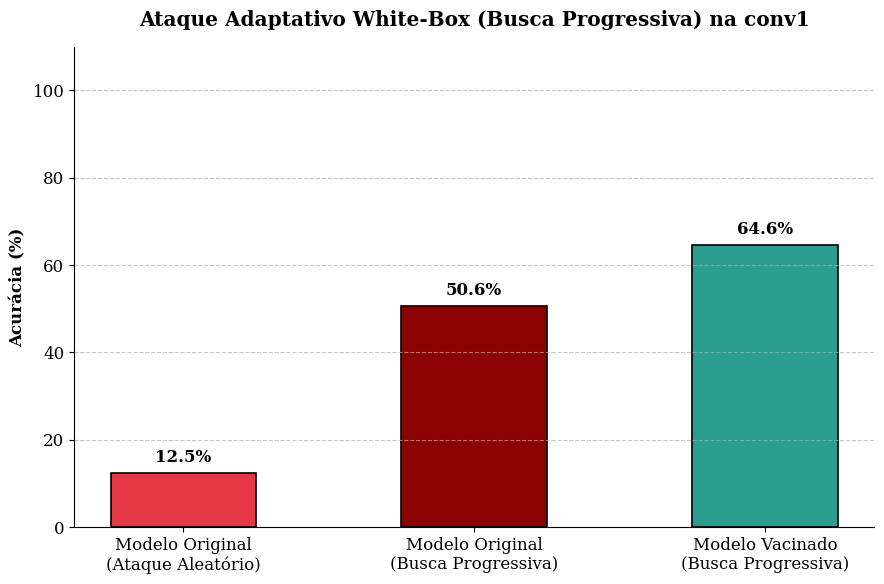


✅ Resultados numéricos salvos na planilha: c:\Users\Herbert\Desktop\LSD\resultados_paper\resultado_adaptativo_progressivo_ResNet18.csv

🚀 EXPERIMENTO PROGRESSIVO ADAPTATIVO CONCLUÍDO!


In [11]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt

print("\n==================================================================")
print("   INICIANDO PIPELINE: ATAQUE PROGRESSIVO ADAPTATIVO (WHITE-BOX)")
print("==================================================================")

# 1. Configurações Iniciais
device = torch.device("cpu")
model_name = "ResNet18"
camada_alvo = "conv1"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_limpo = f"{model_name}_cifar10_treinado.pth"
caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# 2. Preparando Dados
print("\n[*] Preparando Datasets (Cache de Teste)...")
transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# 3. Carregando os Modelos
print(f"\n[*] Carregando os modelos do disco...")
modelo_original = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
modelo_original.fc = nn.Linear(modelo_original.fc.in_features, 10)
modelo_original.load_state_dict(torch.load(caminho_modelo_limpo, map_location=device))
modelo_original = modelo_original.to(device)
modelo_original.eval()

modelo_vacinado = copy.deepcopy(modelo_original).to(device)
modelo_vacinado.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
modelo_vacinado.eval()

# ------------------------------------------------------------------------------
# 4. MOTOR DA BUSCA PROGRESSIVA (Isolado em Função)
# ------------------------------------------------------------------------------
def rodar_busca_progressiva(modelo_alvo, nome_modelo_print, n_busca=100, n_flips=6):
    print(f"\n--- INICIANDO CAÇADA PROGRESSIVA PARA O {nome_modelo_print} ---")
    
    modulo_alvo = dict(modelo_alvo.named_modules())[camada_alvo]
    pesos_float = modulo_alvo.weight.data.view(-1)
    n_pesos_total = pesos_float.numel()
    
    w_max = pesos_float.abs().max().item()
    scale = w_max / 127.0 if w_max > 0 else 1.0
    
    indices_travados = []
    backups_originais = {}
    
    modelo_alvo.eval()
    
    for passo in range(n_flips):
        print(f"[*] Passo {passo+1}/{n_flips}: Procurando sinergia com o combo {indices_travados}...")
        
        # Sorteia 100 candidatos novos para testar
        candidatos = []
        while len(candidatos) < n_busca:
            idx = random.randint(0, n_pesos_total - 1)
            if idx not in indices_travados and idx not in candidatos:
                candidatos.append(idx)
                
        melhor_candidato = None
        pior_acc_deste_passo = 100.0
        
        for idx in tqdm(candidatos, desc=f"Testando candidatos do passo {passo+1}", leave=False):
            with torch.no_grad():
                peso_backup = pesos_float[idx].item()
                
                # Injeta a falha no candidato atual
                p_int8 = int(round(peso_backup / scale))
                p_int8 = max(-128, min(127, p_int8))
                p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
                p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
                pesos_float[idx] = p_flip_int8 * scale
                
                # Mede o estrago total (os travados anteriores já estão injetados na rede)
                out = modelo_alvo(cached_subset[0])
                _, predi = torch.max(out, 1)
                acc = (predi == cached_subset[1]).sum().item() / SUBSET_SIZE * 100
                
                # Tira a falha do candidato para testar o próximo
                pesos_float[idx] = peso_backup
                
                if acc < pior_acc_deste_passo:
                    pior_acc_deste_passo = acc
                    melhor_candidato = idx
                    
        # Fim do passo: elege o candidato mais destrutivo e o "trava" fisicamente na rede
        indices_travados.append(melhor_candidato)
        backups_originais[melhor_candidato] = pesos_float[melhor_candidato].item()
        
        p_int8 = int(round(backups_originais[melhor_candidato] / scale))
        p_int8 = max(-128, min(127, p_int8))
        p_flip_int8 = ((p_int8 & 0xFF) ^ (1 << 7))
        p_flip_int8 = p_flip_int8 if p_flip_int8 < 128 else p_flip_int8 - 256
        pesos_float[melhor_candidato] = p_flip_int8 * scale
        
        print(f"    -> Alvo {melhor_candidato} adicionado e travado! Acurácia do combo caiu para: {pior_acc_deste_passo:.2f}%")
        
    # Após achar os 6, precisamos limpar a rede curando todos os backups para não atrapalhar o próximo modelo
    for idx, val in backups_originais.items():
        pesos_float[idx] = val
        
    print(f"✅ Caçada Progressiva do {nome_modelo_print} finalizada!")
    print(f" -> Combo final do ataque: {indices_travados} (Acurácia final: {pior_acc_deste_passo:.2f}%)\n")
    
    return indices_travados, pior_acc_deste_passo

# ------------------------------------------------------------------------------
# 5. AS DUAS CAÇADAS (O Teste Adaptativo)
# ------------------------------------------------------------------------------
# A. Ataque Progressivo no Original
ataque_no_original, acc_original_atacado = rodar_busca_progressiva(
    modelo_original, "MODELO ORIGINAL", n_busca=100, n_flips=6
)

# B. Ataque Progressivo no Vacinado
ataque_no_vacinado, acc_vacinado_atacado = rodar_busca_progressiva(
    modelo_vacinado, "MODELO VACINADO", n_busca=100, n_flips=6
)

# ------------------------------------------------------------------------------
# 6. O GRÁFICO FINAL
# ------------------------------------------------------------------------------
print("[*] Gerando gráfico do Ataque Progressivo Adaptativo...")
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, ax = plt.subplots(figsize=(9, 6))

cenarios = ['Modelo Original\n(Ataque Aleatório)', 'Modelo Original\n(Busca Progressiva)', 'Modelo Vacinado\n(Busca Progressiva)']
acuracias = [12.5, acc_original_atacado, acc_vacinado_atacado]
cores = ['#E63946', '#8B0000', '#2A9D8F'] 

barras = ax.bar(cenarios, acuracias, color=cores, width=0.5, edgecolor='black', linewidth=1.2)

for barra in barras:
    altura = barra.get_height()
    ax.annotate(f'{altura:.1f}%', xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Acurácia (%)', fontweight='bold')
ax.set_title(f'Ataque Adaptativo White-Box (Busca Progressiva) na {camada_alvo}', fontweight='bold', pad=15)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
caminho_grafico_png = os.path.join(SAVE_DIR, f"grafico_adaptativo_progressivo_{model_name}.png")
plt.savefig(caminho_grafico_png, dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# 7. SALVANDO RESULTADOS NUMÉRICOS (CSV)
# ------------------------------------------------------------------------------
caminho_csv = os.path.join(SAVE_DIR, f"resultado_adaptativo_progressivo_{model_name}.csv")
try:
    with open(caminho_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Modelo", "Camada_Alvo", "Metodo_Ataque", "Indices_Orig", "Acc_Orig", "Indices_Vac", "Acc_Vac"])
        writer.writerow([
            model_name, camada_alvo, "Progressivo Adaptativo", 
            str(ataque_no_original), round(acc_original_atacado, 2), 
            str(ataque_no_vacinado), round(acc_vacinado_atacado, 2)
        ])
    print(f"\n✅ Resultados numéricos salvos na planilha: {caminho_csv}")
except Exception as e:
    print(f"\n⚠️ Erro ao salvar o CSV: {e}")

print("\n🚀 EXPERIMENTO PROGRESSIVO ADAPTATIVO CONCLUÍDO!")

Cria modelo de vulnerabilidades da nova rede vacinada

In [2]:
import os
import csv
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models 
import torch.optim as optim          
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm                
from mrfi import MRFI, EasyConfig
from mrfi.experiment import Acc_golden

print("\n==================================================================")
print("   INICIANDO RADAR MLBFA (FASES 1 E 2) - MODELO VACINADO")
print("==================================================================")

# ==============================================================================
# CONFIGURAÇÕES INICIAIS
# ==============================================================================
device = torch.device("cpu")
model_name = "ResNet18"
SAVE_DIR = r"c:\Users\Herbert\Desktop\LSD\resultados_paper"
os.makedirs(SAVE_DIR, exist_ok=True)

caminho_modelo_vacinado = f"{model_name}_cifar10_vacinado.pth"
SUBSET_SIZE = 512
BATCH_SIZE = 128

# --- Funções Matemáticas Auxiliares (FPC e Estatística) ---
def calcular_e_goal_adaptativo(std_dev):
    if std_dev > 0.10: return 0.015
    elif std_dev > 0.05: return 0.03
    else: return 0.05

def fpc_margin_of_error(p, n, N, confidence=0.99):
    Z = 2.576 
    if n >= N: return 0.0
    p = max(min(p, 0.99999), 0.00001)
    return Z * np.sqrt((p * (1 - p) / n) * ((N - n) / (N - 1)))

def compute_n_with_fpc(N, e_goal, p=0.5, confidence=0.99):
    Z = 2.576
    n0 = (Z**2 * p * (1 - p)) / (e_goal**2)
    n = (n0 * N) / (n0 + (N - 1))
    return int(np.ceil(n))

def evaluate_model(model, x, y, batch_size):
    """Função compatível com a chamada 'fi_corr, _ = evaluate_model(...)'"""
    with torch.no_grad():
        out = model(x)
        _, preds = torch.max(out, 1)
        corrects = (preds == y).sum().item()
    return corrects, 0.0 
# ---------------------------------------------------------

# ==============================================================================
# PREPARANDO DADOS (CACHE)
# ==============================================================================
print("\n[*] Carregando Datasets (Cache em Memória)...")
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
test_ds = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
subset_loader = DataLoader(Subset(test_ds, range(SUBSET_SIZE)), batch_size=BATCH_SIZE, shuffle=False)

all_x, all_y = [], []
for xs, ys in subset_loader:
    all_x.append(xs); all_y.append(ys)
cached_subset = (torch.cat(all_x).to(device), torch.cat(all_y).to(device))

# ==============================================================================
# CARREGANDO O MODELO VACINADO
# ==============================================================================
print(f"\n[*] Preparando a arquitetura {model_name}...")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10) 
model = model.to(device)

if os.path.exists(caminho_modelo_vacinado):
    print(f"✅ Arquivo '{caminho_modelo_vacinado}' encontrado!")
    print("[*] Carregando a rede vacinada para o escaneamento...")
    model.load_state_dict(torch.load(caminho_modelo_vacinado, map_location=device))
else:
    raise FileNotFoundError("⚠️ ERRO: Modelo vacinado não encontrado! Rode a vacina primeiro.")

model.eval()

# ==============================================================================
# CONFIGURAÇÃO MRFI (Idêntica à Original)
# ==============================================================================
mrfi_cfg = r"""
faultinject:
  - type: weight
    enabled: True
    quantization:
      method: SymmericQuantization
      dynamic_range: auto
      bit_width: 8
    error_mode:
      method: IntFixedBitFlip
      bit_width: 8
    selector:
      method: RandomPositionByNumber
      n: 1
    module_type: [Conv2d, Linear]
"""
fi_model = MRFI(copy.deepcopy(model).to(device), EasyConfig.load_string(mrfi_cfg))

# Baseline usando o método original Acc_golden
acc_gold_ref = Acc_golden(fi_model, subset_loader, disable_quantization=False)
gold_correct = int(round(acc_gold_ref * SUBSET_SIZE))
print(f"[*] Golden INT8 (Vacinado): {acc_gold_ref*100:.2f}%")

# Extração de Targets
layer_nodes = []
for name, module in fi_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)) and getattr(module, 'weight', None) is not None:
        if getattr(module, 'FI_config', None) and module.FI_config.weights:
            layer_nodes.append({
                "name": name, "module": module, "cfg": module.FI_config.weights[0],
                "n_params": module.weight.numel(), "bit_w": 8
            })

fi_model.get_weights_configs().enabled = False

# ==============================================================================
# FASE 1: EXPLORAÇÃO DE VARIÂNCIA (WARM-UP)
# ==============================================================================
print("\n--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---")
WARMUP_INJECTIONS = 30
layer_variances = {}

for node in layer_nodes:
    cfg = node["cfg"]
    N_pairs = node["n_params"] * node["bit_w"]
    
    cfg.selector.method = "FixPositions"
    
    acc_drops = []
    for _ in range(min(WARMUP_INJECTIONS, N_pairs)):
        gid = random.randrange(N_pairs)
        param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
        
        cfg.enabled = True
        cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
        cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
        em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
        em_raw.clear()
        em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
        
        fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
        acc_drops.append((gold_correct - fi_corr) / SUBSET_SIZE)
        cfg.enabled = False
        
    std_dev = float(np.std(acc_drops)) if acc_drops else 0.0
    layer_variances[node["name"]] = std_dev
    print(f"[{node['name']}] StdDev de acc_drop: {std_dev:.4f}")

# ==============================================================================
# FASE 2: INJEÇÃO LAYER-WISE ADAPTATIVA
# ==============================================================================
print("\n--- INICIANDO FASE 2: INJEÇÃO ADAPTATIVA ---")
CONF_LEVEL = 0.99
MAX_ITERS = 15
resultados_csv = [] 

for node in layer_nodes:
    layer_name = node["name"]
    cfg = node["cfg"]
    N_pairs_layer = node["n_params"] * node["bit_w"]
    std_dev = layer_variances[layer_name]
    
    dinamic_e_goal = calcular_e_goal_adaptativo(std_dev)
    print(f"\n[LAYER {layer_name}] Variância={std_dev:.4f} -> E_GOAL Adaptado={dinamic_e_goal:.4f}")
    
    used_ids = set()
    x_success, n_sampled = 0, 0
    n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=0.5, confidence=CONF_LEVEL)
    
    for it in range(MAX_ITERS):
        add_needed = max(1, n_target - n_sampled)
        to_add = []
        while len(to_add) < add_needed and len(used_ids) < N_pairs_layer:
            gid = random.randrange(N_pairs_layer)
            if gid not in used_ids:
                used_ids.add(gid); to_add.append(gid)
                
        for gid in to_add:
            param_idx, bit_idx = gid // node["bit_w"], gid % node["bit_w"]
            cfg.enabled = True
            cfg.selector.args.__dict__.setdefault("raw_dict", {}).clear()
            cfg.selector.args.__dict__.setdefault("raw_dict", {})["positions"] = [param_idx]
            em_raw = cfg.error_mode.args.__dict__.setdefault("raw_dict", {})
            em_raw.clear()
            em_raw["bit_width"] = node["bit_w"]; em_raw["bit"] = bit_idx
            
            fi_corr, _ = evaluate_model(fi_model, cached_subset[0], cached_subset[1], BATCH_SIZE)
            if fi_corr < gold_correct: x_success += 1
            n_sampled += 1
            cfg.enabled = False
            
        P_hat = x_success / max(n_sampled, 1)
        E_hat = fpc_margin_of_error(P_hat, n_sampled, N_pairs_layer, confidence=CONF_LEVEL)
        
        if E_hat <= dinamic_e_goal or n_sampled >= N_pairs_layer:
            print(f"  -> STOP: e_hat ({E_hat:.4f}) <= e_goal ({dinamic_e_goal:.4f}) atingido com {n_sampled} injeções.")
            break
            
        n_target = compute_n_with_fpc(N_pairs_layer, dinamic_e_goal, p=max(min(P_hat, 1-1e-9), 1e-9), confidence=CONF_LEVEL)
        
    resultados_csv.append({
        "modelo": model_name + "_Vacinado",
        "camada": layer_name,
        "n_parametros": node["n_params"],
        "desvio_padrao_fase1": round(std_dev, 6),
        "e_goal_dinamico": round(dinamic_e_goal, 6),
        "injecoes_totais": n_sampled,
        "falhas_encontradas": x_success,
        "P_hat_taxa_falha": round(P_hat, 6),
        "E_hat_erro_final": round(E_hat, 6)
    })

# ==============================================================================
# SALVAMENTO AUTOMÁTICO EM CSV
# ==============================================================================
csv_filename = os.path.join(SAVE_DIR, f"resultados_pos_vacina_{model_name}.csv")

try:
    with open(csv_filename, mode='w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=resultados_csv[0].keys())
        writer.writeheader()
        writer.writerows(resultados_csv)
    print(f"\n🚀 Scanner do Modelo Vacinado Concluído!")
    print(f"✅ Resultados salvos com sucesso em: {csv_filename}")
except Exception as e:
    print(f"\n⚠️ Ocorreu um erro ao salvar o arquivo CSV: {e}")


   INICIANDO RADAR MLBFA (FASES 1 E 2) - MODELO VACINADO

[*] Carregando Datasets (Cache em Memória)...

[*] Preparando a arquitetura ResNet18...
✅ Arquivo 'ResNet18_cifar10_vacinado.pth' encontrado!
[*] Carregando a rede vacinada para o escaneamento...
[*] Golden INT8 (Vacinado): 94.92%

--- INICIANDO FASE 1: EXPLORAÇÃO (30 Injeções por Camada) ---
[conv1] StdDev de acc_drop: 0.0031
[layer1.0.conv1] StdDev de acc_drop: 0.0012
[layer1.0.conv2] StdDev de acc_drop: 0.0009
[layer1.1.conv1] StdDev de acc_drop: 0.0020
[layer1.1.conv2] StdDev de acc_drop: 0.0008
[layer2.0.conv1] StdDev de acc_drop: 0.0022
[layer2.0.conv2] StdDev de acc_drop: 0.0011
[layer2.0.downsample.0] StdDev de acc_drop: 0.0021
[layer2.1.conv1] StdDev de acc_drop: 0.0009
[layer2.1.conv2] StdDev de acc_drop: 0.0005
[layer3.0.conv1] StdDev de acc_drop: 0.0006
[layer3.0.conv2] StdDev de acc_drop: 0.0000
[layer3.0.downsample.0] StdDev de acc_drop: 0.0012
[layer3.1.conv1] StdDev de acc_drop: 0.0004
[layer3.1.conv2] StdDev de

Verifica a distribuíção dos pesos

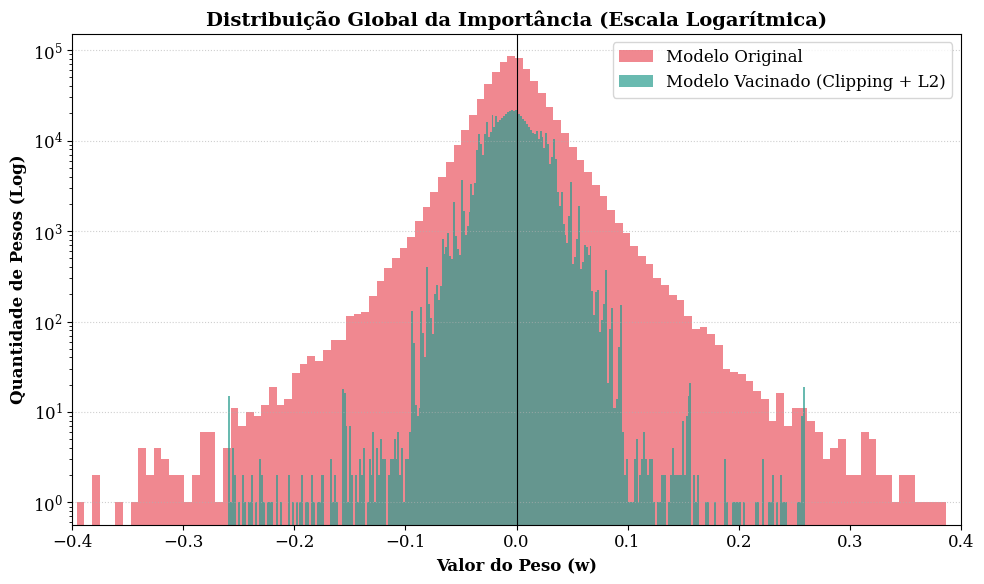

🚀 Gráfico de distribuição salvo em: c:\Users\Herbert\Desktop\LSD\resultados_paper\distribuicao_pesos_comparativa_log.png


In [40]:
plt.figure(figsize=(10, 6))

# A grande mágica está no log=True
plt.hist(pesos_orig, bins=300, log=True, color='#E63946', alpha=0.6, label='Modelo Original')
plt.hist(pesos_vac, bins=300, log=True, color='#2A9D8F', alpha=0.7, label='Modelo Vacinado (Clipping + L2)')

plt.title('Distribuição Global da Importância (Escala Logarítmica)', fontweight='bold', fontsize=14)
plt.xlabel('Valor do Peso (w)', fontweight='bold')
plt.ylabel('Quantidade de Pesos (Log)', fontweight='bold')

# Vamos dar um zoom nas áreas onde as anomalias costumam ficar
plt.xlim(-0.4, 0.4) 

plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

caminho_grafico = os.path.join(SAVE_DIR, "distribuicao_pesos_comparativa_log.png")
plt.tight_layout()
plt.savefig(caminho_grafico, dpi=300)
plt.show()

print(f"🚀 Gráfico de distribuição salvo em: {caminho_grafico}")